In [24]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.style as style
from matplotlib.dates import YearLocator, DateFormatter
import pandas as pd
import matplotlib.cm as cm
import numpy as np
import seaborn as sns
%matplotlib inline 
exchange_rates = pd.read_csv("euro-daily-hist_1999_2022.csv")
exchange_rates.head()

,Period\Unit:,[Australian dollar ],[Bulgarian lev ],[Brazilian real ],[Canadian dollar ],[Swiss franc ],[Chinese yuan renminbi ],[Cypriot pound ],[Czech koruna ],[Danish krone ],...,[Romanian leu ],[Russian rouble ],[Swedish krona ],[Singapore dollar ],[Slovenian tolar ],[Slovak koruna ],[Thai baht ],[Turkish lira ],[US dollar ],[South African rand ]
0,2025-04-02,1.7146,1.9558,6.1212,1.5479,0.9543,7.8529,NaN,24.963,7.4611,...,4.9775,NaN,10.764,1.4508,NaN,NaN,36.93,40.9573,1.0803,20.1042
1,2025-04-01,1.7255,1.9558,6.1679,1.5529,0.952,7.8431,NaN,24.954,7.4616,...,4.9774,NaN,10.816,1.4492,NaN,NaN,36.846,40.9201,1.0788,19.7741
2,2025-03-31,1.7318,1.9558,6.2507,1.5533,0.9531,7.8442,NaN,24.962,7.4613,...,4.9771,NaN,10.849,1.4519,NaN,NaN,36.706,41.0399,1.0815,19.8782
3,2025-03-28,1.712,1.9558,6.2252,1.5444,0.9525,7.8445,NaN,24.96,7.4616,...,4.9774,NaN,10.82,1.4481,NaN,NaN,36.664,41.0387,1.0797,19.6113
4,2025-03-27,1.7101,1.9558,6.2154,1.5425,0.9524,7.8361,NaN,24.982,7.4605,...,4.9773,NaN,10.8235,1.445,NaN,NaN,36.529,40.9940,1.0785,19.7061


In [25]:
exchange_rates.info()
exchange_rates.rename(columns={
    "[US dollar ]": "US_dollar",
    "Period\\Unit:": "Time"
}, inplace=True)
exchange_rates["Time"] = pd.to_datetime(exchange_rates["Time"])
exchange_rates.sort_values("Time", inplace=True)
exchange_rates.reset_index(drop=True, inplace=True)

euro_to_dollar = exchange_rates[["Time", "US_dollar"]]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6785 entries, 0 to 6784
Data columns (total 41 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Period\Unit:              6785 non-null   object 
 1   [Australian dollar ]      6785 non-null   object 
 2   [Bulgarian lev ]          6383 non-null   object 
 3   [Brazilian real ]         6517 non-null   object 
 4   [Canadian dollar ]        6785 non-null   object 
 5   [Swiss franc ]            6785 non-null   object 
 6   [Chinese yuan renminbi ]  6517 non-null   object 
 7   [Cypriot pound ]          2346 non-null   object 
 8   [Czech koruna ]           6785 non-null   object 
 9   [Danish krone ]           6785 non-null   object 
 10  [Estonian kroon ]         3130 non-null   object 
 11  [UK pound sterling ]      6785 non-null   object 
 12  [Greek drachma ]          520 non-null    object 
 13  [Hong Kong dollar ]       6785 non-null   object 
 14  [Croatia

In [26]:
euro_to_dollar["US_dollar"].value_counts()

US_dollar
-         62
1.2276     9
1.0888     8
1.0867     8
1.0808     8
          ..
1.0426     1
1.0299     1
1.0389     1
1.0435     1
1.0498     1
Name: count, Length: 3837, dtype: int64

In [27]:
euro_to_dollar = euro_to_dollar[euro_to_dollar["US_dollar"] != "-"]
euro_to_dollar["US_dollar"] = euro_to_dollar["US_dollar"].astype(float)
type(euro_to_dollar["US_dollar"][1])

numpy.float64

In [28]:
exchange_rates.head()

,Time,[Australian dollar ],[Bulgarian lev ],[Brazilian real ],[Canadian dollar ],[Swiss franc ],[Chinese yuan renminbi ],[Cypriot pound ],[Czech koruna ],[Danish krone ],...,[Romanian leu ],[Russian rouble ],[Swedish krona ],[Singapore dollar ],[Slovenian tolar ],[Slovak koruna ],[Thai baht ],[Turkish lira ],US_dollar,[South African rand ]
0,1999-01-04,1.9100,NaN,NaN,1.8004,1.6168,NaN,0.58231,35.107,7.4501,...,1.3111,25.2875,9.4696,1.9554,189.0450,42.991,42.6799,0.3723,1.1789,6.9358
1,1999-01-05,1.8944,NaN,NaN,1.7965,1.6123,NaN,0.58230,34.917,7.4495,...,1.3168,26.5876,9.4025,1.9655,188.7750,42.848,42.5048,0.3728,1.1790,6.7975
2,1999-01-06,1.8820,NaN,NaN,1.7711,1.6116,NaN,0.58200,34.850,7.4452,...,1.3168,27.4315,9.3050,1.9699,188.7000,42.778,42.6949,0.3722,1.1743,6.7307
3,1999-01-07,1.8474,NaN,NaN,1.7602,1.6165,NaN,0.58187,34.886,7.4431,...,1.3092,26.9876,9.1800,1.9436,188.8000,42.765,42.1678,0.3701,1.1632,6.8283
4,1999-01-08,1.8406,NaN,NaN,1.7643,1.6138,NaN,0.58187,34.938,7.4433,...,1.3143,27.2075,9.1650,1.9537,188.8400,42.560,42.5590,0.3718,1.1659,6.7855


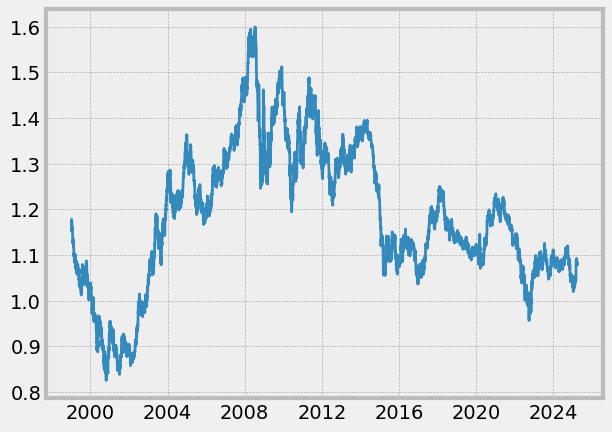

In [29]:
plt.plot(euro_to_dollar["Time"],
         euro_to_dollar["US_dollar"])
plt.show()

In [30]:
euro_to_dollar["rolling_mean"] = euro_to_dollar["US_dollar"].rolling(30).mean()
euro_to_dollar

,Time,US_dollar,rolling_mean
0,1999-01-04,1.1789,NaN
1,1999-01-05,1.1790,NaN
2,1999-01-06,1.1743,NaN
3,1999-01-07,1.1632,NaN
4,1999-01-08,1.1659,NaN
...,...,...,...
6780,2025-03-27,1.0785,1.068030
6781,2025-03-28,1.0797,1.069093
6782,2025-03-31,1.0815,1.070233
6783,2025-04-01,1.0788,1.071370


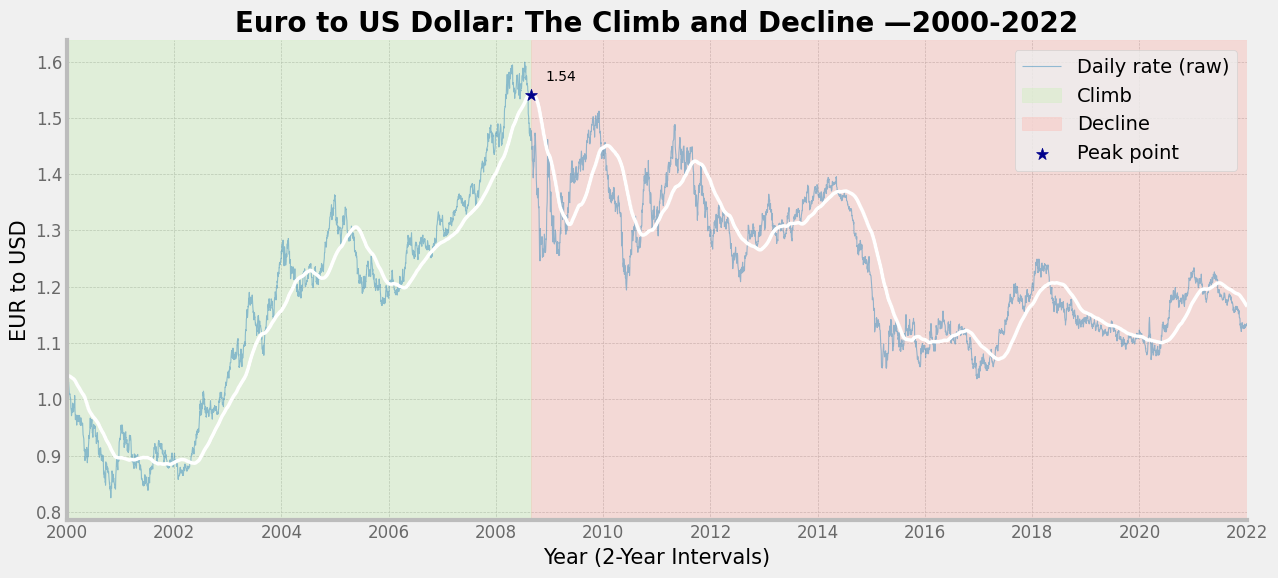

In [32]:
euro_to_dollar["Time"]=pd.to_datetime(euro_to_dollar["Time"])
euro_to_dollar["150_roll"] = euro_to_dollar["US_dollar"].rolling(window=150).mean()
x = euro_to_dollar["Time"].to_numpy()
y = euro_to_dollar["150_roll"].to_numpy()

mask_pre2000 = euro_to_dollar["Time"] < "2000-01-01"
low_idx = np.argmin(y[mask_pre2000])
mask_2020 = (euro_to_dollar["Time"] >= "2005-01-01") & (euro_to_dollar["Time"] <= "2022-01-01")
peak_idx = np.argmax(y[mask_2020])
peak_idx = np.where(mask_2020)[0][peak_idx]
low_x, low_y = x[low_idx], y[low_idx]
peak_x, peak_y = x[peak_idx], y[peak_idx]

plt.style.use("bmh")

fig, ax = plt.subplots(figsize=(13,6))

#Raw Dta Plot
start = "2000-01-01"
end = "2022-12-31"
mask = (euro_to_dollar["Time"] >= start) & (euro_to_dollar["Time"] <= end)
df = euro_to_dollar.loc[mask].copy()
#^Raw
ax.plot(df["Time"], df["US_dollar"],
        linewidth=0.8, alpha=0.50, label="Daily rate (raw)")

ax.plot(x[low_idx:peak_idx+1], y[low_idx:peak_idx+1],
        color="#ffffff", linewidth=2.5)

ax.plot(x[peak_idx:], y[peak_idx:],
        color="#ffffff", linewidth=2.5)
ax.axvspan(low_x, peak_x, color="#c7f0b3", alpha=0.35, label="Climb")
ax.axvspan(peak_x, x[-1], color="#ffb3ab", alpha=0.35, label="Decline")

ax.set_xlim(pd.Timestamp("2000-01-01"), pd.Timestamp("2022-01-01"))
ax.xaxis.set_major_locator(YearLocator(2))
ax.xaxis.set_major_formatter(DateFormatter("%Y"))

ax.set_xlabel("Year (2-Year Intervals)", fontsize=15, fontweight='light')
ax.set_ylabel("EUR to USD", fontsize=15, fontweight='light')
ax.set_title("Euro to US Dollar: The Climb and Decline —2000-2022", fontsize=20, fontweight="bold", color="black")

ax.scatter(peak_x, peak_y, color='darkblue', s=80, marker="*", zorder=3, label='Peak point')
ax.annotate(f'{low_y:.2f}', (low_x, low_y), xytext=(-30,10), textcoords='offset points', fontsize=10)
ax.annotate(f'{peak_y:.2f}', (peak_x, peak_y), xytext=(10,10), textcoords='offset points', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='x', colors='dimgray', labelsize=12)
ax.tick_params(axis='y', colors='dimgray', labelsize=12)
ax.legend()
plt.tight_layout()
plt.show()